# SENTIMENT ANALYSIS: USING RECURRENT NEURAL NETWORK (RNN)

We will represent each token using the pretrained GloVe model, and feed these token representations into a multilayer bidirectional RNN to obtain the text sequence representation, which will be transformed into sentiment analysis outputs. For the same downstream application, we will consider a different architectural choice later.

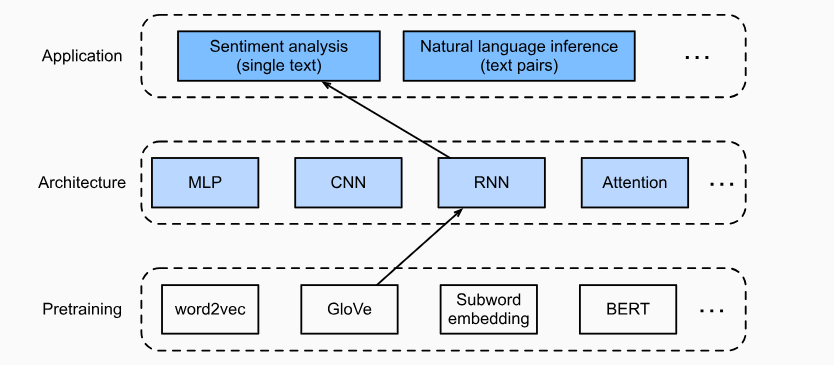

In [1]:
import torch
from torch import nn
from utils import spy

c:\Users\DELL\.conda\envs\torch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
batch_size = 64
train_iter, test_iter, vocab = spy.load_data_imdb(batch_size)

## STEP 1 - Representing single text with RNNs

In text classifications tasks, such as sentiment analysis, a varying-length text sequence will be transformed into fixed-length categories. In the following `BiRNN` class, while each token of a text sequence gets its individual pretrained GloVe representation via the embedding layer (`self.embedding`), the entire sequence is encoded by a bidirectional RNN (`self.encoder`). More concretely, the hidden states (at the last layer) of the bidirectional LSTM at both the initial and final time steps are concatenated as the representation of the text sequence. This single text representation is then transformed into output categories by a fully connected layer (`self.decoder`) with two outputs (“positive” and “negative”).

In [3]:
class BiRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, **kwargs):
        super().__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.encoder = nn.LSTM(embed_size, num_hiddens, num_layers, bidirectional=True)
        self.decoder = nn.Linear(4 * num_hiddens, 2)


    def forward(self, inputs):
        # default: batch_first = True -> the inputs with shape (batch_size, time_steps)
        # have to be transposed
        embeddings = self.embedding(inputs.T)
        self.encoder.flatten_parameters()
        # outputs = hidden state of all time steps of the last layer 
        outputs, _ = self.encoder(embeddings)
        encoding = torch.cat((outputs[0], outputs[-1]), dim=1)
        outs = self.decoder(encoding)
        return outs

Let’s construct a bidirectional RNN with two hidden layers to represent single text for sentiment analysis.

In [4]:
embed_size, num_hiddens, num_layers, devices = 100, 128, 2, spy.try_all_gpus()
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)

def _init_weights(module):
    if type(module) == nn.Linear:
        nn.init.xavier_uniform_(module.weight)
    if type(module) == nn.LSTM:
        for param in module._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(module._parameters[param])

net.apply(_init_weights)

BiRNN(
  (embedding): Embedding(49346, 100)
  (encoder): LSTM(100, 128, num_layers=2, bidirectional=True)
  (decoder): Linear(in_features=512, out_features=2, bias=True)
)

## STEP 2 - Loading pretrained word vectors

Below we load the pretrained 100-dimensional (needs to be consistent with `embed_size`) GloVe embeddings for tokens in the vocabulary.



In [5]:
glove_embedding = spy.TokenEmbedding('http://d2l-data.s3-accelerate.amazonaws.com/glove.6B.100d.zip')

Print the shape of the vectors for all the tokens in the vocabulary.

In [6]:
embeds = glove_embedding[vocab.idx_to_token]
embeds.shape

torch.Size([49346, 100])

We use these pretrained word vectors to represent tokens in the reviews and will not update these vectors during training.

In [7]:
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

## STEP 3 - Training and evaluating the model

KeyboardInterrupt: 

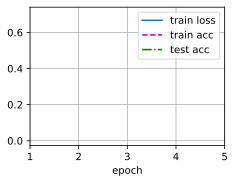

In [8]:
lr, num_epochs = 0.01, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction='none')
spy.train(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

We define the following function to predict the sentiment of a text sequence using the trained model net.



In [ ]:
def predict_sentiment(net, vocab, sentence):
    """Predict the sentiment of a text sequence"""
    sequence = torch.tensor(
        vocab[sentence.split()], device='cuda' if torch.cuda.is_available() else 'cpu')
    preds = torch.argmax(net(sequence.reshape(1, -1)), dim=1)
    return 'positive' if preds == 1 else 'negative'

Finally, let’s use the trained model to predict the sentiment for two simple sentences.

In [ ]:
predict_sentiment(net, vocab, 'this movie is so great')

In [ ]:
predict_sentiment(net, vocab, 'this movie is so bad')